# Multi-Stock Analysis: 100 Largest S&P 500 Constituents
-------------------------------------------------------
Steps:
  1. Define the 100 largest S&P 500 stocks by market cap (as of early 2025)
  2. Download 2500 days of adjusted OHLC data via yfinance
  3. Compute daily log returns per stock → wide & long DataFrames
  4. Plot a histogram of ALL daily log returns (pooled across stocks)
  5. Compute per-stock rolling 100-day Z-scores (no lookahead)


In [2]:
# Install dependencies: 
# import sys !{sys.executable} -m pip install yfinance pandas numpy matplotlib

In [3]:
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

# ─────────────────────────────────────────────────────────────────────────────
# 1. THE 100 LARGEST S&P 500 CONSTITUENTS  (by approximate market cap rank) - hard-coded list
# ─────────────────────────────────────────────────────────────────────────────

In [16]:
TOP100 = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "BRK-B", "AVGO", "GD",
    "JPM",  "LLY",  "V",    "UNH",  "XOM",   "MA",   "COST", "HD",    "PG",   "JNJ",
    "ABBV", "BAC",  "NFLX", "CRM",  "WMT",   "CVX",  "MRK",  "ORCL",  "KO",   "AMD",
    "PEP",  "ACN",  "TMO",  "MCD",  "LIN",   "CSCO", "ABT",  "ADBE",  "DHR",  "TXN",
    "NKE",  "PM",   "NEE",  "AMGN", "QCOM",  "IBM",  "RTX",  "INTU",  "SPGI", "GE",
    "HON",  "CAT",  "LOW",  "UPS",  "ELV",   "ISRG", "AMAT", "GS",    "AXP",  "BKNG",
    "SYK",  "BLK",  "VRTX", "PLD",  "MDLZ",  "ADI",  "GILD", "TRV",   "DE",   "SBUX",
    "ETN",  "ADP",  "LRCX", "CI",   "MO",    "SO",   "DUK",  "PGR",   "BSX",  "ZTS",
    "PANW", "CME",  "AON",  "REGN", "SLB",   "BDX",  "KLAC", "NOC",   "MU",   "ITW",
    "TJX",  "SNPS", "CDNS", "PYPL",   "MCO",   "EOG",  "WM",   "APH",   "CTAS", "HCA",
]

In [17]:
print(f"Universe: {len(TOP100)} tickers")

Universe: 100 tickers


# ─────────────────────────────────────────────────────────────────────────────
# 2. DOWNLOAD ADJUSTED OHLC  (2500 calendar days ≈ ~10 years of trading data)
# ─────────────────────────────────────────────────────────────────────────────

In [18]:
PERIOD = "2500d"   # yfinance period string

print(f"\nDownloading {PERIOD} of data for all {len(TOP100)} tickers …")
print("(This may take 30–60 seconds)\n")

raw = yf.download(
    TOP100,
    period=PERIOD,
    auto_adjust=True,      # Adjusts OHLC for splits & dividends
    group_by="ticker",     # raw[ticker][OHLC]
    threads=True,
    progress=True,
)


(This may take 30–60 seconds)



[*********************100%***********************]  100 of 100 completed


In [19]:
print(raw.shape)

(2500, 500)


# Reshape into a clean MultiIndex DataFrame: (Date, Ticker) → OHLC

In [20]:
frames = []
for ticker in TOP100:
    try:
        df = raw[ticker][["Open", "High", "Low", "Close"]].copy()
        df.dropna(how="all", inplace=True)
        if df.empty:
            print(f" WARNING: No data for {ticker}, skipping.")
            continue
        df["Ticker"] = ticker
        frames.append(df)
    except KeyError:
        print(f" WARNING: {ticker} not found in download, skipping.")

prices_long = pd.concat(frames).reset_index()          # columns: Date, Open, High, Low, Close, Ticker
prices_long.sort_values(["Ticker", "Date"], inplace=True)
prices_long.reset_index(drop=True, inplace=True)

In [21]:
# Wide close-price table for vectorised operations
close_wide = prices_long.pivot(index="Date", columns="Ticker", values="Close")

tickers_available = list(close_wide.columns)
print(f"\nSuccessfully loaded {len(tickers_available)} tickers.")
print(f"Date range : {close_wide.index[0].date()}  →  {close_wide.index[-1].date()}")
print(f"Trading days: {len(close_wide)}\n")
print("── Sample close prices (last 3 rows, first 6 tickers) ──")
print(close_wide.iloc[-3:, :6])


Successfully loaded 100 tickers.
Date range : 2016-06-03  →  2026-05-13
Trading days: 2500

── Sample close prices (last 3 rows, first 6 tickers) ──
Ticker            AAPL        ABBV        ABT         ACN        ADBE  \
Date                                                                    
2026-05-11  292.679993  202.779999  82.559998  172.350006  246.149994   
2026-05-12  294.799988  207.860001  84.349998  169.770004  240.830002   
2026-05-13  298.869995  208.500000  83.830002  159.639999  236.070007   

Ticker             ADI  
Date                    
2026-05-11  422.730011  
2026-05-12  419.649994  
2026-05-13  432.390015  


In [22]:
print(close_wide.shape)
print(close_wide.columns)

(2500, 100)
Index(['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADP', 'AMAT', 'AMD',
       'AMGN', 'AMZN', 'AON', 'APH', 'AVGO', 'AXP', 'BAC', 'BDX', 'BKNG',
       'BLK', 'BRK-B', 'BSX', 'CAT', 'CDNS', 'CI', 'CME', 'COST', 'CRM',
       'CSCO', 'CTAS', 'CVX', 'DE', 'DHR', 'DUK', 'ELV', 'EOG', 'ETN', 'GD',
       'GE', 'GILD', 'GOOGL', 'GS', 'HCA', 'HD', 'HON', 'IBM', 'INTU', 'ISRG',
       'ITW', 'JNJ', 'JPM', 'KLAC', 'KO', 'LIN', 'LLY', 'LOW', 'LRCX', 'MA',
       'MCD', 'MCO', 'MDLZ', 'META', 'MO', 'MRK', 'MSFT', 'MU', 'NEE', 'NFLX',
       'NKE', 'NOC', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PG', 'PGR', 'PLD', 'PM',
       'PYPL', 'QCOM', 'REGN', 'RTX', 'SBUX', 'SLB', 'SNPS', 'SO', 'SPGI',
       'SYK', 'TJX', 'TMO', 'TRV', 'TSLA', 'TXN', 'UNH', 'UPS', 'V', 'VRTX',
       'WM', 'WMT', 'XOM', 'ZTS'],
      dtype='object', name='Ticker')


# ─────────────────────────────────────────────────────────────────────────────
# 3. DAILY LOG RETURNS  =  log(Close_t / Close_{t-1})  per stock
# ─────────────────────────────────────────────────────────────────────────────

In [23]:
returns_wide = np.log(close_wide / close_wide.shift(1))   # wide: Date × Ticker
returns_wide.dropna(how="all", inplace=True)

# Long format is handy for plotting and aggregation
returns_long = (
    returns_wide
    .reset_index()
    .melt(id_vars="Date", var_name="Ticker", value_name="Log_Return")
    .dropna(subset=["Log_Return"])
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

print(f"\n── Log Returns (wide) — {returns_wide.shape[0]} rows × {returns_wide.shape[1]} tickers ──")
print(returns_wide.iloc[-3:, :6])


── Log Returns (wide) — 2499 rows × 100 tickers ──
Ticker          AAPL      ABBV       ABT       ACN      ADBE       ADI
Date                                                                  
2026-05-11 -0.001263  0.006084 -0.021094 -0.045760 -0.027606  0.014799
2026-05-12  0.007217  0.024743  0.021450 -0.015083 -0.021850 -0.007313
2026-05-13  0.013712  0.003074 -0.006184 -0.061523 -0.019963  0.029907


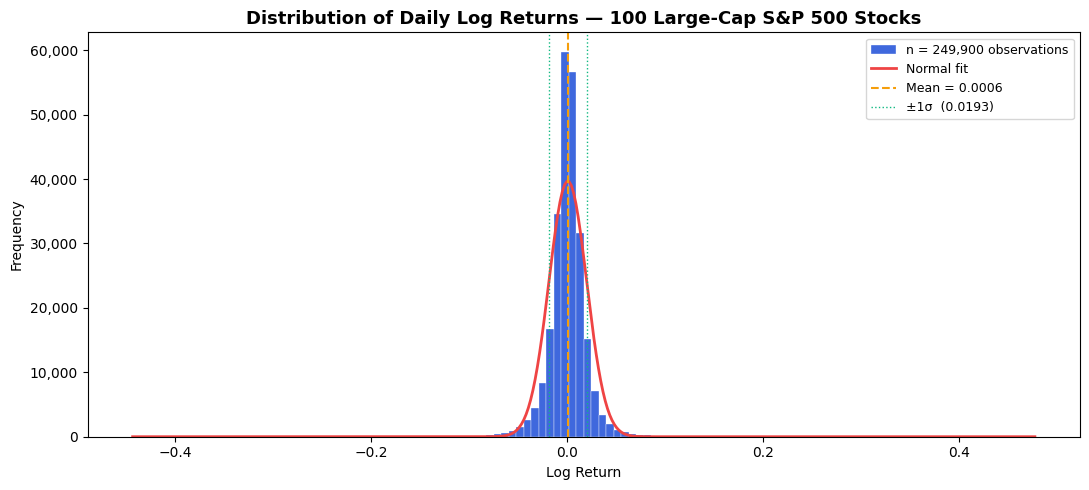

Histogram saved → returns_histogram_100stocks.png


In [24]:
all_returns = returns_long["Log_Return"].values
mu_pool     = np.nanmean(all_returns)
sig_pool    = np.nanstd(all_returns)

fig, ax = plt.subplots(figsize=(11, 5))

n, bins, _ = ax.hist(
    all_returns,
    bins=120,
    color="#1D4ED8",
    edgecolor="white",
    linewidth=0.3,
    alpha=0.85,
    label=f"n = {len(all_returns):,} observations",
)

# Overlay fitted normal curve
x      = np.linspace(all_returns.min(), all_returns.max(), 400)
pdf    = np.exp(-0.5 * ((x - mu_pool) / sig_pool) ** 2) / (sig_pool * np.sqrt(2 * np.pi))
bin_w  = bins[1] - bins[0]
ax.plot(x, pdf * len(all_returns) * bin_w, color="#EF4444", linewidth=2, label="Normal fit")

ax.axvline(mu_pool,            color="#F59E0B", linewidth=1.5, linestyle="--", label=f"Mean = {mu_pool:.4f}")
ax.axvline(mu_pool + sig_pool, color="#10B981", linewidth=1,   linestyle=":",  label=f"±1σ  ({sig_pool:.4f})")
ax.axvline(mu_pool - sig_pool, color="#10B981", linewidth=1,   linestyle=":")

ax.set_title(
    f"Distribution of Daily Log Returns — {len(tickers_available)} Large-Cap S&P 500 Stocks",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Log Return")
ax.set_ylabel("Frequency")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("returns_histogram_100stocks.png", dpi=150)
plt.show()
print("Histogram saved → returns_histogram_100stocks.png")


# ─────────────────────────────────────────────────────────────────────────────
# 5. ROLLING 100-DAY Z-SCORES  (per stock, no lookahead)
#
#    For each stock on day t:
#      window  = returns on days [t-100 … t-1]   (shift(1) excludes today)
#      $\mu_t$    = mean(window)
#      $\sigma_t$ = std(window)
#      $Z_t     = (r_t − \mu_t) / \sigma_t$
# ─────────────────────────────────────────────────────────────────────────────

In [25]:
WINDOW = 100

shifted = returns_wide.shift(1)                        # exclude today from the window

roll_mu    = shifted.rolling(window=WINDOW).mean()     # Date × Ticker
roll_sigma = shifted.rolling(window=WINDOW).std()

zscore_wide = (returns_wide - roll_mu) / roll_sigma    # Date × Ticker
zscore_wide.dropna(how="all", inplace=True)

In [26]:
print(returns_wide.shape)
print(shifted.shape)
print(roll_mu.shape)
print(roll_sigma.shape)
print(zscore_wide.shape)

(2499, 100)
(2499, 100)
(2499, 100)
(2499, 100)
(2399, 100)


In [27]:
# Assemble a tidy long DataFrame with all columns
zscore_long = (
    returns_wide
    .join(roll_mu.add_suffix("_mu"))
    .join(roll_sigma.add_suffix("_sigma"))
    .join(zscore_wide.add_suffix("_z"))
    .dropna(how="all")
    .reset_index()
    .melt(
        id_vars="Date",
        value_vars=(
            [t for t in tickers_available] +
            [f"{t}_mu" for t in tickers_available] +
            [f"{t}_sigma" for t in tickers_available] +
            [f"{t}_z" for t in tickers_available]
        ),
        var_name="Series",
        value_name="Value",
    )
)

In [30]:
print(zscore_long.shape)
print(zscore_long.head(3))
print(zscore_long.tail(3))

(999600, 3)
        Date Series     Value
0 2016-06-06   AAPL  0.007225
1 2016-06-07   AAPL  0.004047
2 2016-06-08   AAPL -0.000909
             Date Series     Value
999597 2026-05-11  ZTS_z -2.540491
999598 2026-05-12  ZTS_z  0.267551
999599 2026-05-13  ZTS_z -0.998834


# Cleaner per-ticker long table

In [31]:
def _stack_wide(df_wide, col_name):
	# small helper that converts a wide DataFrame into a long one.
	# Wide format (input) has one row per date and one column per ticker
	# Long format (output) has one row per date/ticker combination, 
	# with a single value column named whatever you pass as col_name:
	
    return (
        df_wide.reset_index()
        .melt(id_vars="Date", var_name="Ticker", value_name=col_name)
    )

In [32]:
zscores_tidy = (
    _stack_wide(returns_wide, "Log_Return")
    .merge(_stack_wide(roll_mu,    "Rolling_Mu"),    on=["Date", "Ticker"])
    .merge(_stack_wide(roll_sigma, "Rolling_Sigma"), on=["Date", "Ticker"])
    .merge(_stack_wide(zscore_wide,"Z_Score"),        on=["Date", "Ticker"])
    .dropna(subset=["Z_Score"])
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

print(f"\n── Z-Score DataFrame ({len(zscores_tidy):,} rows) ──")
print(zscores_tidy[zscores_tidy["Ticker"] == tickers_available[0]].tail(8).to_string(index=False))


── Z-Score DataFrame (239,900 rows) ──
      Date Ticker  Log_Return  Rolling_Mu  Rolling_Sigma   Z_Score
2026-05-04   AAPL   -0.011886    0.000058       0.014634 -0.816174
2026-05-05   AAPL    0.026204   -0.000029       0.014679  1.787081
2026-05-06   AAPL    0.011650    0.000259       0.014909  0.764023
2026-05-07   AAPL   -0.000244    0.000318       0.014943 -0.037559
2026-05-08   AAPL    0.020250    0.000342       0.014940  1.332533
2026-05-11   AAPL   -0.001263    0.000536       0.015072 -0.119374
2026-05-12   AAPL    0.007217    0.000674       0.014990  0.436499
2026-05-13   AAPL    0.013712    0.000728       0.015004  0.865334


In [33]:
print(zscores_tidy.shape)

(239900, 6)


In [34]:
print(zscores_tidy.head(3))
print(zscores_tidy.tail(3))

        Date Ticker  Log_Return  Rolling_Mu  Rolling_Sigma   Z_Score
0 2016-10-26   AAPL   -0.022752    0.001941       0.012435 -1.985637
1 2016-10-27   AAPL   -0.009649    0.001641       0.012666 -0.891380
2 2016-10-28   AAPL   -0.006661    0.001504       0.012714 -0.642186
             Date Ticker  Log_Return  Rolling_Mu  Rolling_Sigma   Z_Score
239897 2026-05-11    ZTS   -0.077280   -0.003509       0.029038 -2.540491
239898 2026-05-12    ZTS    0.003515   -0.004475       0.029866  0.267551
239899 2026-05-13    ZTS   -0.034377   -0.004624       0.029787 -0.998834


# Quick summary: most extreme Z-scores in the most recent session

In [36]:
latest_date = zscores_tidy["Date"].max()
latest       = zscores_tidy[zscores_tidy["Date"] == latest_date].copy()
latest.sort_values("Z_Score", inplace=True)

print(f"\n── Most extreme Z-scores on {latest_date.date()} ──")
print("LOWEST (most oversold):")
print(latest[["Ticker","Log_Return","Rolling_Mu","Rolling_Sigma","Z_Score"]].head(5).to_string(index=False))
print("\nHIGHEST (most overbought):")
print(latest[["Ticker","Log_Return","Rolling_Mu","Rolling_Sigma","Z_Score"]].tail(5).to_string(index=False))


── Most extreme Z-scores on 2026-05-13 ──
LOWEST (most oversold):
Ticker  Log_Return  Rolling_Mu  Rolling_Sigma   Z_Score
   ACN   -0.061523   -0.004631       0.026120 -2.178096
   TJX   -0.021730   -0.000288       0.011645 -1.841286
  SPGI   -0.042427   -0.001619       0.022497 -1.813977
    HD   -0.025809   -0.001208       0.016171 -1.521237
   MCO   -0.030180   -0.000852       0.020589 -1.424420

HIGHEST (most overbought):
Ticker  Log_Return  Rolling_Mu  Rolling_Sigma  Z_Score
   SYK    0.025616   -0.001725       0.016230 1.684566
 GOOGL    0.038664    0.002346       0.018734 1.938685
  PANW    0.054999    0.001418       0.026766 2.001841
   JNJ    0.027098    0.000743       0.010112 2.606201
   CME    0.039052    0.000695       0.013181 2.910187


# Z-score time-series plot for a sample of tickers

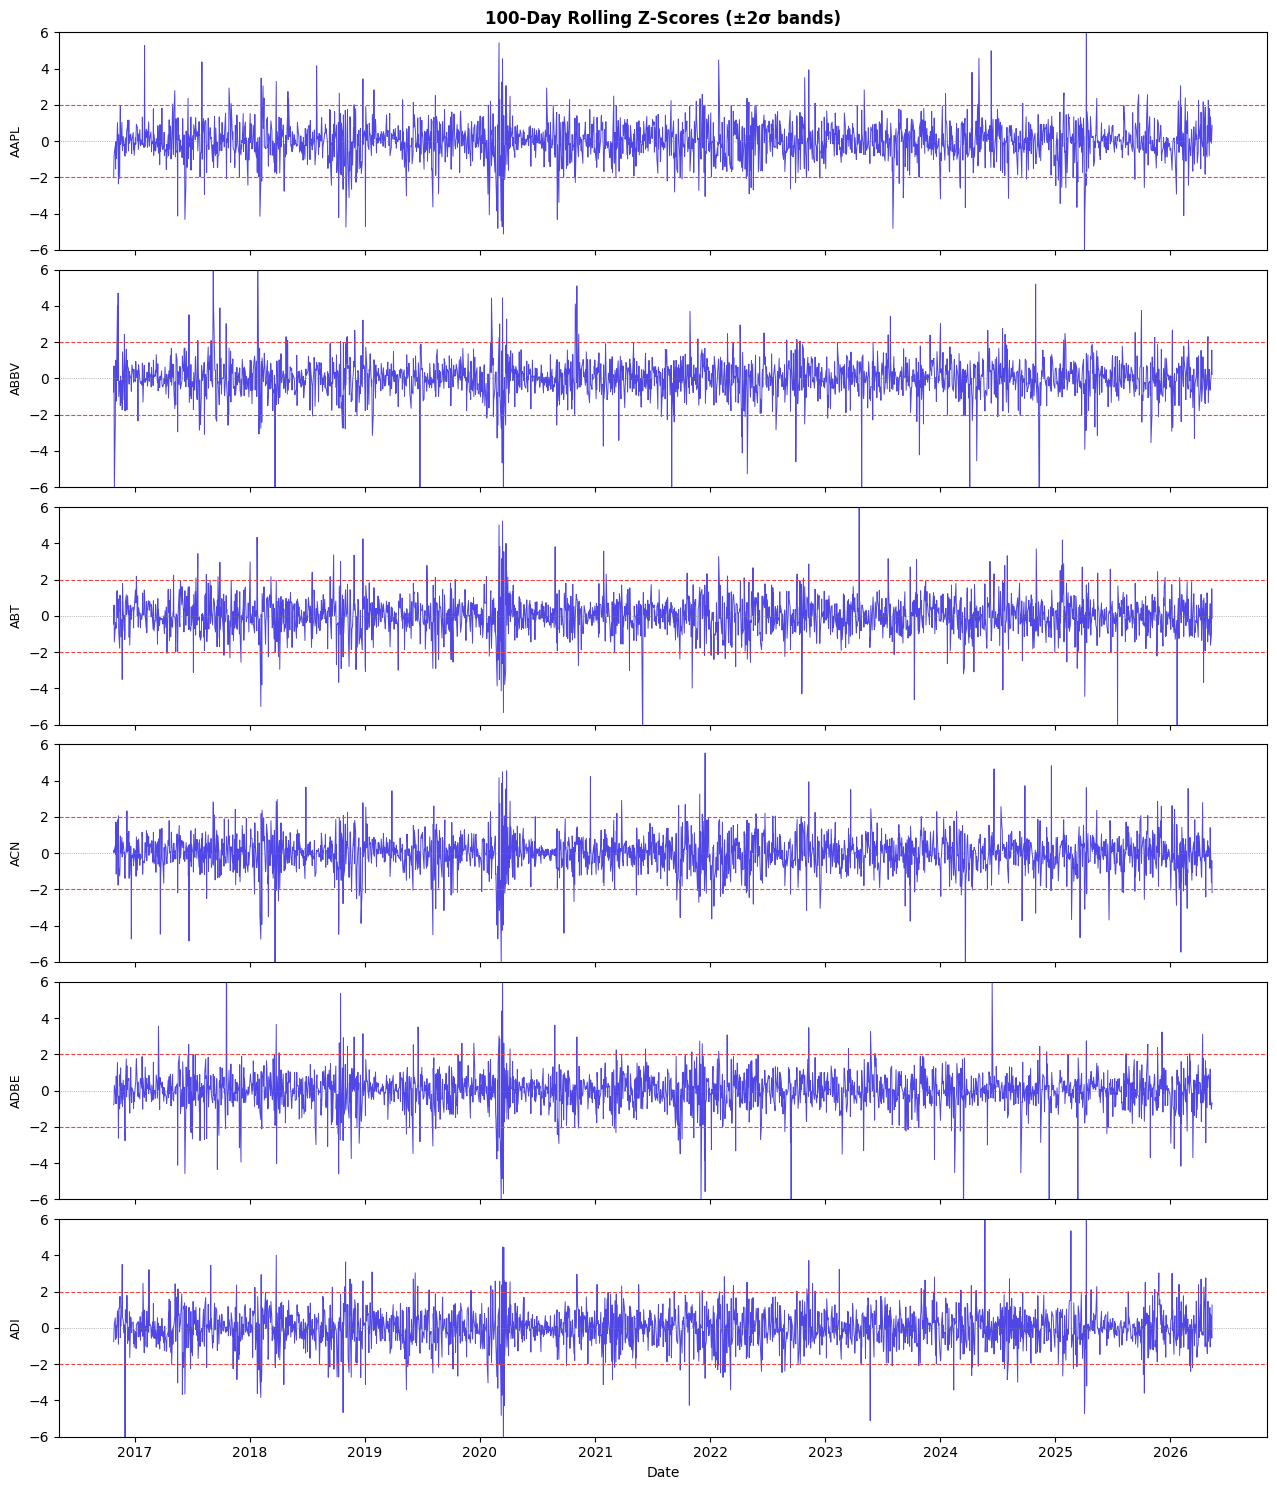


Z-score plot saved → zscore_timeseries_100stocks.png


In [37]:
SAMPLE_TICKERS = tickers_available[:6]

fig2, axes = plt.subplots(len(SAMPLE_TICKERS), 1, figsize=(13, 2.5 * len(SAMPLE_TICKERS)), sharex=True)

for ax, ticker in zip(axes, SAMPLE_TICKERS):
    sub = zscores_tidy[zscores_tidy["Ticker"] == ticker]
    ax.plot(sub["Date"], sub["Z_Score"], linewidth=0.7, color="#4F46E5")
    ax.axhline( 2, color="#EF4444", linewidth=0.8, linestyle="--")
    ax.axhline(-2, color="#EF4444", linewidth=0.8, linestyle="--")
    ax.axhline( 0, color="gray",    linewidth=0.5, linestyle=":")
    ax.set_ylabel(ticker, fontsize=9)
    ax.set_ylim(-6, 6)

axes[0].set_title("100-Day Rolling Z-Scores (±2σ bands)", fontsize=12, fontweight="bold")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("zscore_timeseries_100stocks.png", dpi=150)
plt.show()
print("\nZ-score plot saved → zscore_timeseries_100stocks.png")

# Check final outputs

In [38]:
print("\n── Objects available for further analysis ──")
print(f"  prices_long   : {prices_long.shape}   (Date, Ticker, OHLC)")
print(f"  close_wide    : {close_wide.shape}   (Date × Ticker, adjusted close)")
print(f"  returns_wide  : {returns_wide.shape}   (Date × Ticker, log returns)")
print(f"  returns_long  : {returns_long.shape}   (Date, Ticker, Log_Return)")
print(f"  zscore_wide   : {zscore_wide.shape}   (Date × Ticker, Z-scores)")
print(f"  zscores_tidy  : {zscores_tidy.shape}   (Date, Ticker, Return, Mu, Sigma, Z)")
print("\nDone ✓")


── Objects available for further analysis ──
  prices_long   : (250000, 6)   (Date, Ticker, OHLC)
  close_wide    : (2500, 100)   (Date × Ticker, adjusted close)
  returns_wide  : (2499, 100)   (Date × Ticker, log returns)
  returns_long  : (249900, 3)   (Date, Ticker, Log_Return)
  zscore_wide   : (2399, 100)   (Date × Ticker, Z-scores)
  zscores_tidy  : (239900, 6)   (Date, Ticker, Return, Mu, Sigma, Z)

Done ✓
